In [31]:
import pandas as pd
import matplotlib.pyplot as plt

#read the data from the CSV file
Regression_DF = pd.read_csv("C:\Projects\Battery Engineering\Summary Files\Regression_Results (Phase_3).csv")

EOL_DF = pd.read_csv("C:\Projects\Battery Engineering\Summary Files\Battery_Cycle_Estimation .csv")

Filtered_Regression_DF = Regression_DF[(Regression_DF['Segment'] == 'No Spike') | (Regression_DF['Segment'] == 'Post Spike')]

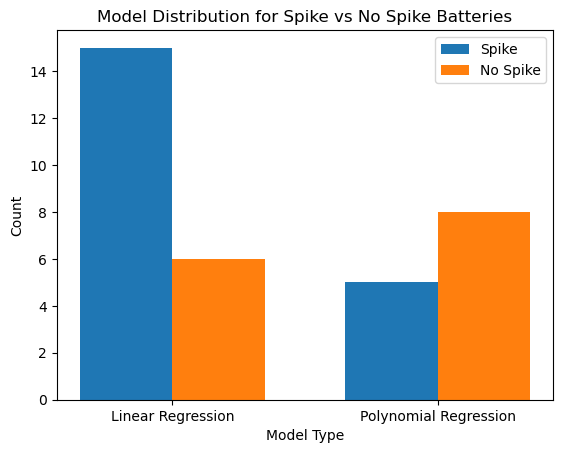

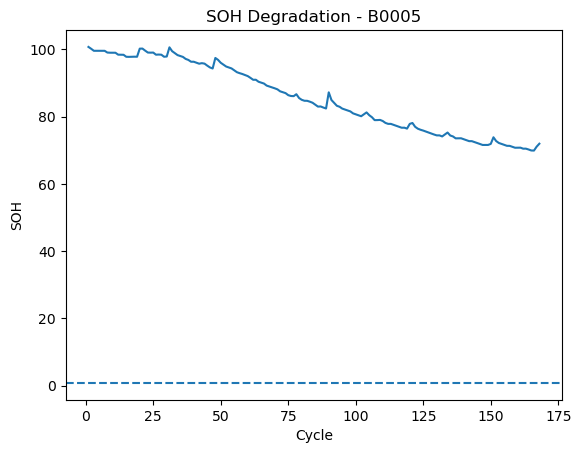

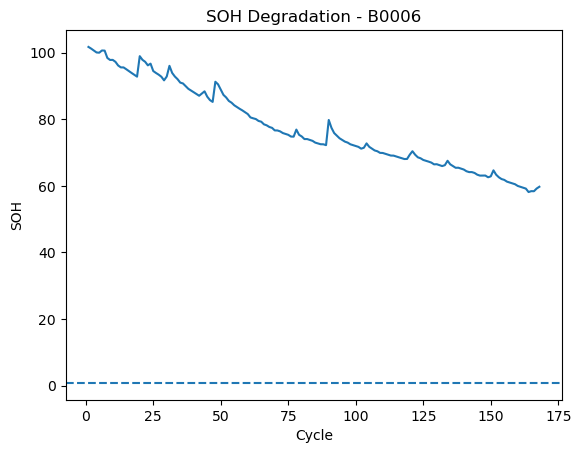

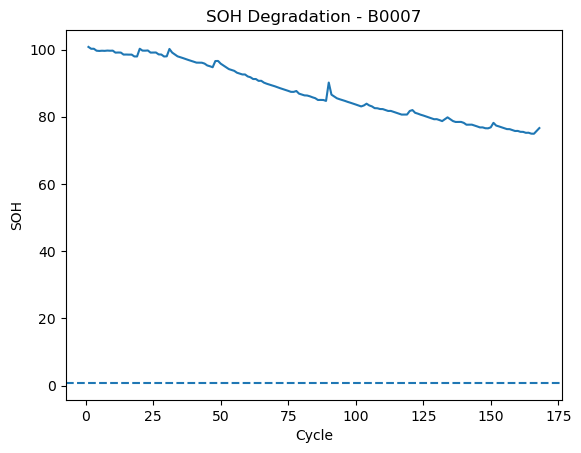

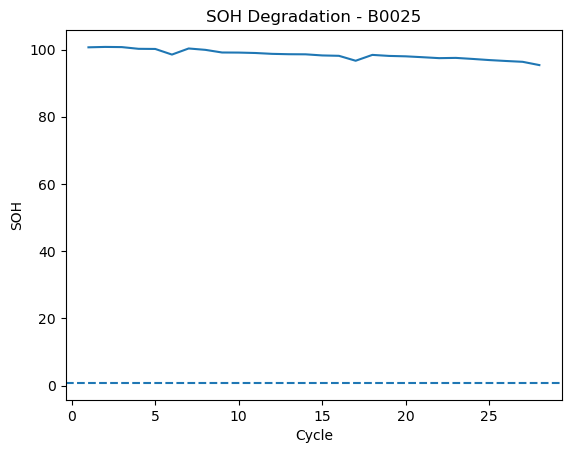

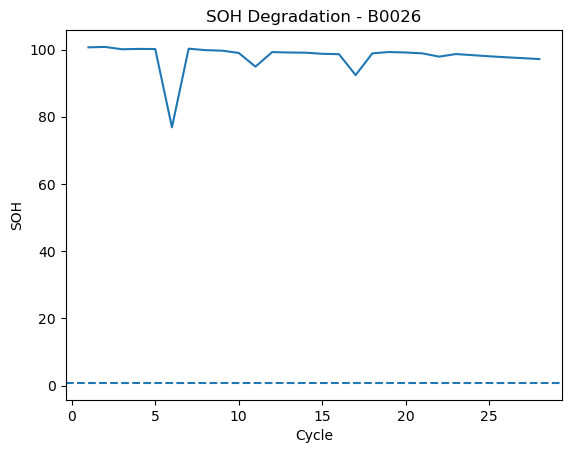

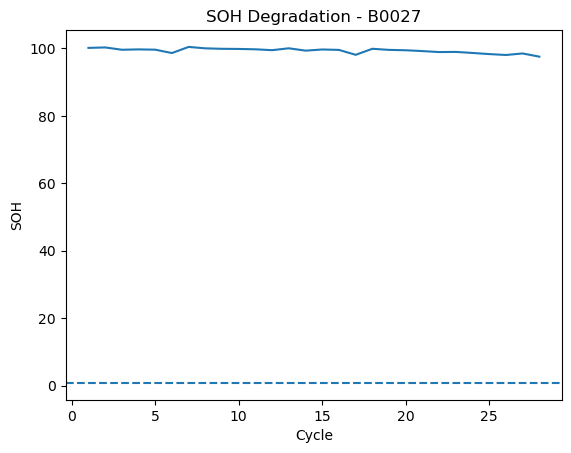

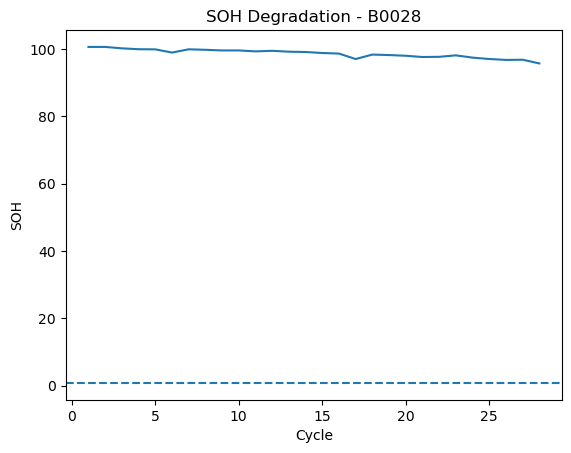

In [ ]:
#Preparing Summary Statistics for Regression_DF
import numpy as np
#Modeules With and Without Spike
Spike_Count = Regression_DF[Regression_DF['Segment'] == 'Pre Spike']['Model'].value_counts()
No_Spike_Count = Regression_DF[Regression_DF['Segment'] == 'No Spike']['Model'].value_counts()
   
summary_df = pd.DataFrame({
    'Spike': Spike_Count,
    'No Spike': No_Spike_Count
}).fillna(0)


x = np.arange(len(summary_df.index))
width = 0.35

plt.bar(x - width/2, summary_df['Spike'], width, label='Spike')
plt.bar(x + width/2, summary_df['No Spike'], width, label='No Spike')

plt.xticks(x, summary_df.index)
plt.xlabel("Model Type")
plt.ylabel("Count")
plt.title("Model Distribution for Spike vs No Spike Batteries")
plt.legend()

plt.show()




#Linear and Polynomia Counts 
Linear_Count = Regression_DF[Regression_DF['Model'] == 'Linear'].shape[0]
Polynomial_Count = Regression_DF[Regression_DF['Model'] == 'Polynomial'].shape[0]



#Visualization of degradation (Multiple Batteries)
Battery = ['B0005', 'B0006', 'B0007', 'B0025', 'B0026', 'B0027', 'B0028']
for battery in Battery:
    path = f"C:\\Projects\\Battery Engineering\\Summary Files\\Overall Summary\\{battery}_Overall_Summary.csv"
    Battery_DF = pd.read_csv(path)

    plt.plot(Battery_DF['Cycle Pair'], Battery_DF['SOH'])
    plt.axhline(0.8, linestyle='--')
    plt.title(f"SOH Degradation - {battery}")
    plt.xlabel("Cycle")
    plt.ylabel("SOH")
    plt.show()




In [36]:
#Average Error Calculation 
Avg_linear_Error_Train = Regression_DF[Regression_DF['Model'] == 'Linear Regression']['Train_MAE'].mean()
Avg_polynomial_Error_Train = Regression_DF[Regression_DF['Model'] == 'Polynomial Regression']['Train_MAE'].mean()
Avg_linear_Error_Test = Regression_DF[Regression_DF['Model'] == 'Linear Regression']['Test_MAE'].mean()
Avg_polynomial_Error_Test = Regression_DF[Regression_DF['Model'] == 'Polynomial Regression']['Test_MAE'].mean()

Avg_Squared_Error_Train = Regression_DF[Regression_DF['Model'] == 'Linear Regression']['Train_MSE'].mean()
Avg_Squared_Error_Test = Regression_DF[Regression_DF['Model'] == 'Linear Regression']['Test_MSE'].mean()
Avg_Squared_Error_Polynomial_Train = Regression_DF[Regression_DF['Model'] == 'Polynomial Regression']['Train_MSE'].mean()
Avg_Squared_Error_Polynomial_Test = Regression_DF[Regression_DF['Model'] == 'Polynomial Regression']['Test_MSE'].mean()

overall_train_error = Regression_DF['Train_MAE'].mean()
overall_test_error = Regression_DF['Test_MAE'].mean()

Error_Results = {
    'Linear - Train': Avg_linear_Error_Train,
    'Polynomial - Train': Avg_polynomial_Error_Train,
    'Linear - Test': Avg_linear_Error_Test,
    'Polynomial - Test': Avg_polynomial_Error_Test,
    'Linear - Squared - Train': Avg_Squared_Error_Train,
    'Linear - Squared - Test': Avg_Squared_Error_Test,
    'Polynomial - Squared - Train': Avg_Squared_Error_Polynomial_Train,
    'Polynomial - Squared - Test': Avg_Squared_Error_Polynomial_Test,
    'Overall_Train_Error': overall_train_error,
    'Overall_Test_Error': overall_test_error
}

print("Average Error Results:")
for key, value in Error_Results.items():
    print(f"{key}: {value}")

Average Error Results:
Linear - Train: 2.1005952647884687
Polynomial - Train: 0.4480205461527022
Linear - Test: 4.714280000499585
Polynomial - Test: 8.880687132773025
Linear - Squared - Train: 25.2747298166829
Linear - Squared - Test: 148.3395930380373
Polynomial - Squared - Train: 0.45296852143925825
Polynomial - Squared - Test: 653.2582799899708
Overall_Train_Error: 1.7027532028946732
Overall_Test_Error: 5.7173039397505985


# Phase 3: Battery Degradation Modeling and RUL Prediction


Polynomial regression achieves significantly lower training error compared to linear regression. However, the test error for polynomial models is considerably higher, indicating overfitting.

Linear regression demonstrates better generalization performance and provides more stable predictions for unseen battery cycles.

In [ ]:
#Final Summary Statistics for EOL_DF



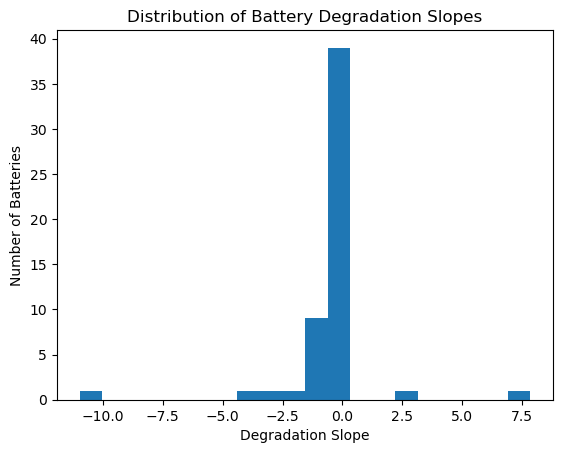

In [23]:
plt.figure()

plt.hist(Regression_DF['Slope'], bins=20)
plt.xlabel("Degradation Slope")
plt.ylabel("Number of Batteries")
plt.title("Distribution of Battery Degradation Slopes")

plt.show()

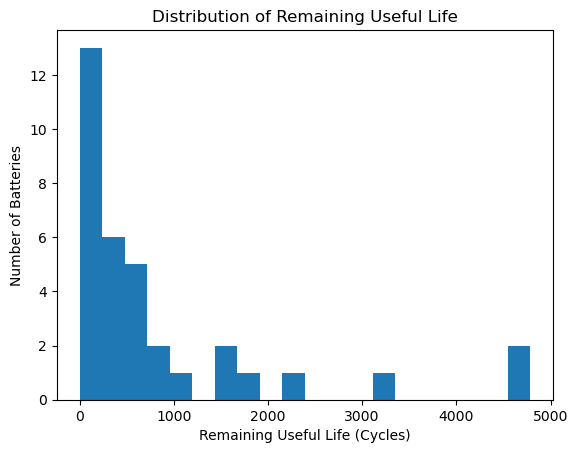

In [32]:
plt.figure()
RUL = pd.to_numeric(EOL_DF['Remaining_Cycles'], errors='coerce')
RUL = RUL.dropna()

plt.hist(RUL, bins=20)

plt.xlabel("Remaining Useful Life (Cycles)")
plt.ylabel("Number of Batteries")
plt.title("Distribution of Remaining Useful Life")

plt.show()